In [ ]:
# Setup & Data Loading 

from sklearn.preprocessing import StandardScaler
import pandas as pd, numpy as np 
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Input, GlobalAveragePooling1D 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau 
import warnings
warnings.filterwarnings("ignore")

# Load
csv_path =  "Location1.csv" # Path to the CSV file
df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} data")

# Column  check
required_cols = {
    'Time','temperature_2m','relativehumidity_2m','dewpoint_2m',
    'windspeed_10m','windspeed_100m','Power'
}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in CSV: {sorted(missing)}")

# Parse time robustly and index
df['Time'] = pd.to_datetime(df['Time'], errors='coerce', dayfirst=False, infer_datetime_format=True)
bad = df['Time'].isna().sum()
if bad:
    print(f"Warning: {bad} rows had unparseable Time and were dropped.")
df = df.dropna(subset=['Time']).sort_values('Time').drop_duplicates(subset=['Time'])
df = df.set_index('Time')

# Identify target, select features
df = df.rename(columns={'Power': 'TARGETVAR'})
features = ['temperature_2m','relativehumidity_2m','dewpoint_2m','windspeed_10m','windspeed_100m']
target = 'TARGETVAR'

Loaded 43,800 data


Hyperparameters

In [ ]:
timesteps   = 24        # hours of history the TCN sees
batch_size  = 32
epochs      = 100
learning_rate = 1e-3

features = features  # keep whatever you defined earlier
target   = 'TARGETVAR'

print(f"Rows: {len(df):,} | Start: {df.index.min()} | End: {df.index.max()}")
print(f"Features ({len(features)}): {features}")

# Separate last 3 months for validation
val_start = df.index.max() - pd.DateOffset(months=13)
val_df = df.loc[df.index > val_start].copy()
train_test_df = df.loc[df.index <= val_start].copy()

print(f"Validation period: {val_df.index.min()} → {val_df.index.max()} ({len(val_df):,} rows)")
print(f"Train + Test period: {train_test_df.index.min()} → {train_test_df.index.max()} ({len(train_test_df):,} rows)")

# Split train_test_df into Train/Test by ratio (0.8/0.2)
split_idx = int(len(train_test_df) * 0.8)
train_df = train_test_df.iloc[:split_idx].copy()
test_df  = train_test_df.iloc[split_idx:].copy()

print(f"Train rows: {len(train_df):,}")
print(f"Test  rows: {len(test_df):,}")
print(f"Val   rows: {len(val_df):,}")


Rows: 43,800 | Start: 2017-01-02 00:00:00 | End: 2021-12-31 23:00:00
Features (5): ['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'windspeed_10m', 'windspeed_100m']
Validation period: 2020-12-01 00:00:00 → 2021-12-31 23:00:00 (9,504 rows)
Train + Test period: 2017-01-02 00:00:00 → 2020-11-30 23:00:00 (34,296 rows)
Train rows: 27,436
Test  rows: 6,860
Val   rows: 9,504


Time-based split (last 6 months for validation)

In [ ]:
# SCALE on TRAIN only (no leakage) 
x_scaler = StandardScaler().fit(train_df[features])
y_scaler = StandardScaler().fit(train_df[[target]])

# Keep the exact input order (features + past target)
in_feature_names = features + [target]
n_features = len(in_feature_names)

def prep_block(block):
    # scale features and target using TRAIN scalers
    Xs = x_scaler.transform(block[features])
    ys = y_scaler.transform(block[[target]])[:, 0]
    # append past TARGETVAR as an input channel
    Xin = np.hstack([Xs, ys.reshape(-1, 1)])
    # cast to float32 for keras speed/stability
    return Xin.astype(np.float32), ys.astype(np.float32)

# order is Train → Val → Test (so you can use Val during .fit and Test for final report)
train_in, train_y = prep_block(train_df)
val_in,   val_y   = prep_block(val_df)
test_in,  test_y  = prep_block(test_df)

print(f"In-feature order: {in_feature_names} (n_features={n_features})")
print("Shapes (rows × features):",
      f"train_in={train_in.shape}, val_in={val_in.shape}, test_in={test_in.shape}")


In-feature order: ['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'windspeed_10m', 'windspeed_100m', 'TARGETVAR'] (n_features=6)
Shapes (rows × features): train_in=(27436, 6), val_in=(9504, 6), test_in=(6860, 6)


Sequence builder (no split leakage)

In [40]:
def create_sequences(data_2d, y_1d, timesteps: int):
    X, y = [], []
    for i in range(len(data_2d) - timesteps):
        X.append(data_2d[i:i+timesteps, :])     # (T, n_features)
        y.append(y_1d[i + timesteps])           # predict next step
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_in, timesteps=timesteps, y_1d=train_y)
X_val,   y_val   = create_sequences(val_in,   timesteps=timesteps, y_1d=val_y)
X_test,  y_test  = create_sequences(test_in,  timesteps=timesteps, y_1d=test_y)

print(f"Seq shapes → X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")


Seq shapes → X_train (27412, 24, 6) | X_val (9480, 24, 6) | X_test (6836, 24, 6)


Build a compact TCN (causal & dilated)

In [41]:
def build_tcn(input_shape, lr=1e-3):
    model = Sequential([
        Input(shape=input_shape),
        # Dilated causal stacks
        Conv1D(64, kernel_size=3, padding='causal', dilation_rate=1, activation='relu'),
        Dropout(0.2),
        Conv1D(64, kernel_size=3, padding='causal', dilation_rate=2, activation='relu'),
        Dropout(0.2),
        Conv1D(64, kernel_size=3, padding='causal', dilation_rate=4, activation='relu'),
        Dropout(0.2),
        # Head
        GlobalAveragePooling1D(),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

model = build_tcn((timesteps, n_features), lr=learning_rate)
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_9 (Conv1D)               │ (None, 24, 64)         │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 24, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 24, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,145 (117.75 KB)

 Trainable params: 30,145 (117.75 KB)

 Non-trainable params: 0 (0.00 B)

Train with validation

In [42]:
callbacks = [
    EarlyStopping(patience=10, monitor='val_loss', restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5, min_lr=1e-5, monitor='val_loss')
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)

final_val_loss_from_fit = history.history['val_loss'][-1]
best_val_loss = float(np.min(history.history['val_loss']))
print(f"\nFinal val_loss (scaled): {final_val_loss_from_fit:.6f}")
print(f"Best  val_loss (scaled): {best_val_loss:.6f}")


Epoch 1/100
857/857 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.1581 - val_loss: 0.0669 - learning_rate: 0.0010
Epoch 2/100
857/857 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0462 - val_loss: 0.0271 - learning_rate: 0.0010
Epoch 3/100
857/857 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0331 - val_loss: 0.0175 - learning_rate: 0.0010
Epoch 4/100
857/857 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0291 - val_loss: 0.0156 - learning_rate: 0.0010
Epoch 5/100
857/857 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0257 - val_loss: 0.0238 - learning_rate: 0.0010
Epoch 6/100
857/857 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0234 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 7/100
857/857 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0221 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 8/100
857/857 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0212 - val_loss: 0.0142 - learning_rate: 0.0010
Epoch 9/100
857/857 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0208 - val_loss: 0.0125 - learning_rate: 0.0010
E

Prediction and Evaluation


--- Test Metrics (original units) ---
MAE :  0.0158
MSE :  0.0005
RMSE:  0.0233
R²  :  0.9934


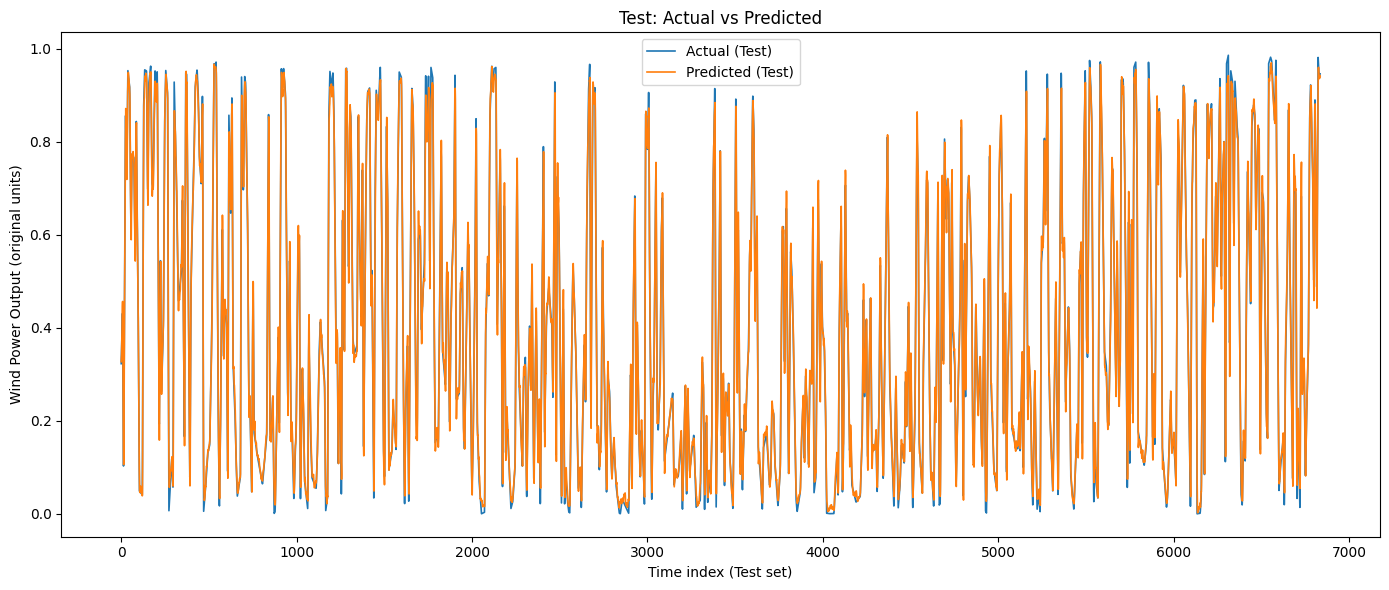

In [43]:
# Predict on test
y_test_pred_scaled = model.predict(X_test, verbose=0).ravel()

# Inverse scaling
y_test_true = y_scaler.inverse_transform(y_test.reshape(-1,1)).ravel()
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1,1)).ravel()

# Metrics
test_mae  = mean_absolute_error(y_test_true, y_test_pred)
test_mse  = mean_squared_error(y_test_true, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2   = r2_score(y_test_true, y_test_pred)

print("\n--- Test Metrics (original units) ---")
print(f"MAE :  {test_mae:.4f}")
print(f"MSE :  {test_mse:.4f}")
print(f"RMSE:  {test_rmse:.4f}")
print(f"R²  :  {test_r2:.4f}")

# Plot
plt.figure(figsize=(14,6))
plt.plot(y_test_true, label='Actual (Test)', linewidth=1.2)
plt.plot(y_test_pred, label='Predicted (Test)', linewidth=1.2)
plt.title('Test: Actual vs Predicted')
plt.xlabel('Time index (Test set)')
plt.ylabel('Wind Power Output (original units)')
plt.legend()
plt.tight_layout()
plt.show()


Prediction on validation


--- Validation Metrics (original units) ---
MAE :  0.0151
MSE :  0.0005
RMSE:  0.0218
R²  :  0.9947


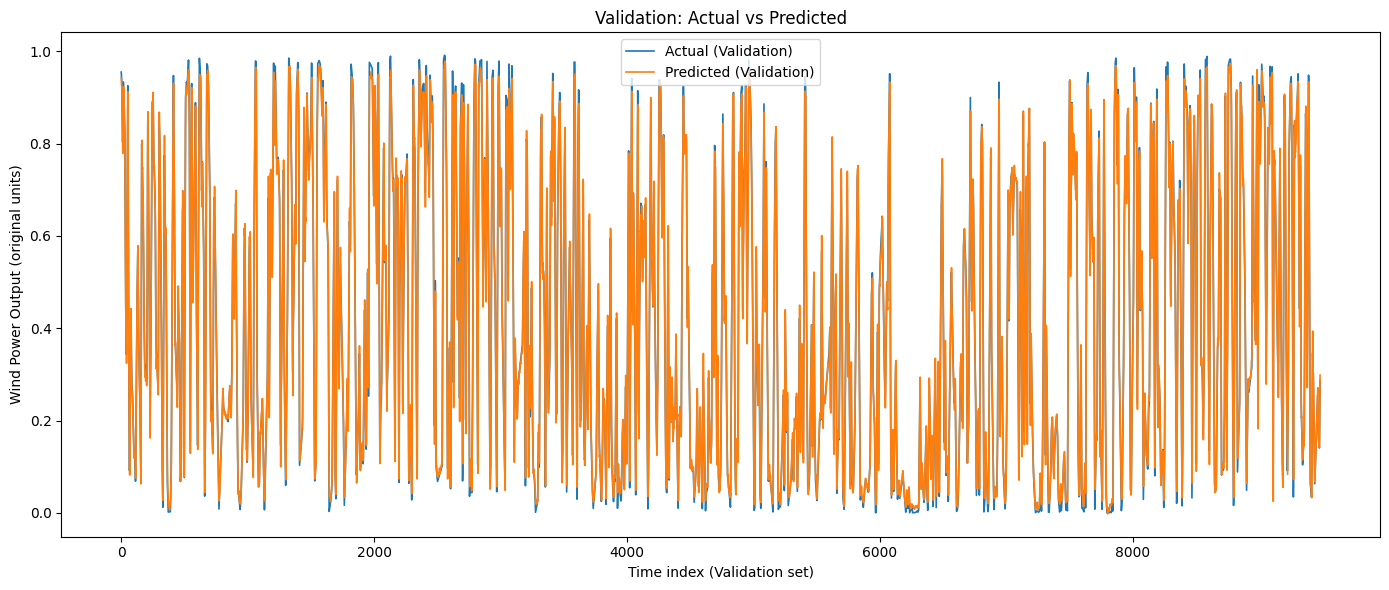

In [44]:

# Predict on validation
y_val_pred_scaled = model.predict(X_val, verbose=0).ravel()

# Inverse scaling
y_val_true = y_scaler.inverse_transform(y_val.reshape(-1,1)).ravel()
y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled.reshape(-1,1)).ravel()

# Metrics
val_mae  = mean_absolute_error(y_val_true, y_val_pred)
val_mse  = mean_squared_error(y_val_true, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2   = r2_score(y_val_true, y_val_pred)

print("\n--- Validation Metrics (original units) ---")
print(f"MAE :  {val_mae:.4f}")
print(f"MSE :  {val_mse:.4f}")
print(f"RMSE:  {val_rmse:.4f}")
print(f"R²  :  {val_r2:.4f}")

# Plot
plt.figure(figsize=(14,6))
plt.plot(y_val_true, label='Actual (Validation)', linewidth=1.2)
plt.plot(y_val_pred, label='Predicted (Validation)', linewidth=1.2)
plt.title('Validation: Actual vs Predicted')
plt.xlabel('Time index (Validation set)')
plt.ylabel('Wind Power Output (original units)')
plt.legend()
plt.tight_layout()
plt.show()
